In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# TheLook eCommerce Business Glossary & Conversational Agent Validation

This notebook builds a semantic foundation for enterprise data by constructing a **Knowledge Catalog Business Glossary** and custom **SQL Mapping Aspects**, followed by validating their governing impact on a **BigQuery Conversational Data Agent**.

### Learning Objectives
1. **Business Taxonomy**: Define hierarchical business categories and terms to establish standardized terminology across the enterprise.
2. **Custom Aspect Registration**: Attach semantic `sql-mapping` Aspects to map non-technical business concepts into concrete SQL filter conditions.
3. **Physical Asset Linking**: Associate glossary terms with underlying BigQuery physical tables and columns.
4. **Conversational Agent Validation**: Build a BigQuery Data Agent using the governed metadata as knowledge sources, testing its capability to translate ambiguous business questions into precise SQL queries.


## Step 1: Environment & REST API Setup

In [ ]:
# [Qwiklabs Environment] If you encounter an HTTP Error 401 (Invalid authentication credentials) during Dataplex API calls,
# uncomment and run the line below to perform manual authentication:
# !gcloud auth application-default login --no-launch-browser --quiet

import json
import ssl
import subprocess
import time
import urllib.error
import urllib.request

import google.auth
from google.auth.transport.requests import AuthorizedSession, Request
from google.cloud import bigquery

# 1. Configuration parameters
GLOSSARY_ID = "thelook-glossary"

# 2. Retrieve Project ID and OAuth2 AuthorizedSession
credentials, PROJECT_ID = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
authed_session = AuthorizedSession(credentials)

bq_client = bigquery.Client(project=PROJECT_ID)
try:
    LOCATION = bq_client.get_dataset("thelook_ecommerce").location
except Exception:
    LOCATION = "us-central1"
REINITIALIZE = False  # Set to True to tear down and rebuild the glossary

# Retrieve Project Number via Cloud Resource Manager API
response = authed_session.get(
    f"https://cloudresourcemanager.googleapis.com/v1/projects/{PROJECT_ID}"
)
PROJECT_NUMBER = response.json()["projectNumber"]

print(
    f"Google Cloud Project ID: {PROJECT_ID} (Project Number: {PROJECT_NUMBER})"
)

## Step 2: Define Common API Helper Functions

In [ ]:
existing_categories = None

# ==========================================
# [Common] REST Request Helper with Exponential Backoff
# ==========================================


def send_rest_request_with_retry(
    url,
    method="POST",
    body=None,
    max_attempts=5,
    ignore_409=True,
    retry_on_403_404=False,
):
    """Centralized REST request helper with exponential backoff and error handling."""
    backoff = 2

    for attempt in range(max_attempts):
        try:
            if method == "GET":
                response = authed_session.get(url, timeout=60)
            elif method == "POST":
                response = authed_session.post(url, json=body, timeout=60)
            elif method == "PATCH":
                response = authed_session.patch(url, json=body, timeout=60)
            elif method == "DELETE":
                response = authed_session.delete(url, timeout=60)
            else:
                response = authed_session.request(
                    method, url, json=body, timeout=60
                )

            if response.status_code < 400:
                return True

            # 409 Conflict: Already exists, treat as success
            if response.status_code == 409 and ignore_409:
                return True
            # 429 Rate Limit: Exponential backoff
            elif response.status_code == 429:
                print(
                    f"    [WAIT] Rate limit (429), waiting before retry (attempt {attempt+1}/{max_attempts})..."
                )
                time.sleep(backoff)
                backoff *= 2
            # 403/404: Propagation delay
            elif response.status_code in (403, 404) and retry_on_403_404:
                print(
                    f"    [WAIT] Waiting for indexing propagation... Retrying in 5s (attempt {attempt+1}/{max_attempts})"
                )
                time.sleep(5)
            else:
                print(
                    f"    [FAIL] API call failed: {response.status_code} - {response.text}"
                )
                return False
        except Exception as e:
            print(f"    [FAIL] API error occurred: {e}")
            if attempt < max_attempts - 1:
                time.sleep(backoff)
                backoff *= 2
            else:
                return False

    print(f"    [FAIL] API call failed (max attempts exceeded)")
    return False


# ==========================================
# Resource Management & Linking Functions
# ==========================================


# 1. Create Category (gcloud CLI)
def get_or_create_category(cat_id, display_name, parent_path):
    global existing_categories
    if existing_categories is None:
        existing_categories = set()
        list_cats = subprocess.run(
            [
                "gcloud",
                "dataplex",
                "glossaries",
                "categories",
                "list",
                f"--glossary={GLOSSARY_ID}",
                f"--location={LOCATION}",
                f"--project={PROJECT_ID}",
                "--format=value(name)",
            ],
            capture_output=True,
            text=True,
        )
        if list_cats.returncode == 0 and list_cats.stdout.strip():
            for cat_path in list_cats.stdout.strip().split("\n"):
                existing_categories.add(cat_path.split("/")[-1])
        print(f"Cached existing categories ({len(existing_categories)} found)")

    if cat_id not in existing_categories:
        print(f"Creating category: {cat_id} ({display_name})...")
        subprocess.run(
            [
                "gcloud",
                "dataplex",
                "glossaries",
                "categories",
                "create",
                cat_id,
                f"--glossary={GLOSSARY_ID}",
                f"--location={LOCATION}",
                f"--project={PROJECT_ID}",
                f"--parent={parent_path}",
                f"--display-name={display_name}",
            ],
            check=True,
        )
        existing_categories.add(cat_id)
        print(f"  Category created: {cat_id}. Waiting for indexing (3s)...")
        time.sleep(3)
    return f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/categories/{cat_id}"


# 2. Create Glossary Term


def create_glossary_term(term_id, display_name, description, parent_path):
    url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms?termId={term_id}"
    body = {
        "displayName": display_name,
        "description": description,
        "parent": parent_path,
    }
    return send_rest_request_with_retry(url, method="POST", body=body)


# 3. Link Term to Table


def link_term_to_table(term_entry_path, bq_entry_path, link_id):
    url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@bigquery/entryLinks?entry_link_id={link_id}"
    body = {
        "entryLinkType": "projects/dataplex-types/locations/global/entryLinkTypes/definition",
        "entryReferences": [
            {"name": bq_entry_path, "type": "SOURCE"},
            {"name": term_entry_path, "type": "TARGET"},
        ],
    }
    return send_rest_request_with_retry(url, method="POST", body=body)


# 4. Link Related Terms


def link_related_terms(term_1_path, term_2_path, link_id):
    url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entryLinks?entry_link_id={link_id}"
    body = {
        "entryLinkType": "projects/dataplex-types/locations/global/entryLinkTypes/related",
        "entryReferences": [
            {"name": term_1_path, "type": "UNSPECIFIED"},
            {"name": term_2_path, "type": "UNSPECIFIED"},
        ],
    }
    return send_rest_request_with_retry(url, method="POST", body=body)


# 5. Link Synonym Terms


def link_synonym_terms(term_1_path, term_2_path, link_id):
    url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entryLinks?entry_link_id={link_id}"
    body = {
        "entryLinkType": "projects/dataplex-types/locations/global/entryLinkTypes/synonym",
        "entryReferences": [
            {"name": term_1_path, "type": "UNSPECIFIED"},
            {"name": term_2_path, "type": "UNSPECIFIED"},
        ],
    }
    return send_rest_request_with_retry(url, method="POST", body=body)


# 6. Create Custom Aspect Type (sql-mapping)


def create_sql_mapping_aspect_type():
    aspect_type_id = "sql-mapping"
    print(f"Checking Aspect Type registration: {aspect_type_id}...")

    # 1. Check if already exists
    check_cmd = subprocess.run(
        [
            "gcloud",
            "dataplex",
            "aspect-types",
            "describe",
            aspect_type_id,
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
            "--format=value(name)",
        ],
        capture_output=True,
        text=True,
    )
    if check_cmd.returncode == 0 and check_cmd.stdout.strip():
        print(f"  Aspect Type already registered: {aspect_type_id}")
        return True

    # 2. Attempt creation via REST API (index is mandatory for recordFields)
    url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/aspectTypes?aspectTypeId={aspect_type_id}"
    body = {
        "displayName": "SQL Mapping Ruleset",
        "description": "SQL mapping ruleset for Text-to-SQL data agents",
        "metadataTemplate": {
            "name": "sql_mapping",
            "type": "record",
            "recordFields": [
                {
                    "name": "type",
                    "type": "string",
                    "index": 1,
                    "constraints": {"required": True},
                },
                {"name": "table", "type": "string", "index": 2},
                {"name": "condition", "type": "string", "index": 3},
                {"name": "expression", "type": "string", "index": 4},
                {"name": "attribute", "type": "string", "index": 5},
            ],
        },
    }
    if send_rest_request_with_retry(url, method="POST", body=body):
        print(f"  Aspect Type created successfully (REST API): {aspect_type_id}")
        return True

    # 3. Fallback to gcloud CLI
    print(
        f"  [Notice] REST API creation failed, attempting via gcloud CLI: {aspect_type_id}..."
    )
    import tempfile

    template_content = {
        "name": "sql_mapping",
        "type": "record",
        "recordFields": [
            {
                "name": "type",
                "type": "string",
                "index": 1,
                "constraints": {"required": True},
            },
            {"name": "table", "type": "string", "index": 2},
            {"name": "condition", "type": "string", "index": 3},
            {"name": "expression", "type": "string", "index": 4},
            {"name": "attribute", "type": "string", "index": 5},
        ],
    }
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile("w", suffix=".json", delete=False) as tmp:
            json.dump(template_content, tmp)
            tmp_path = tmp.name
        res = subprocess.run(
            [
                "gcloud",
                "dataplex",
                "aspect-types",
                "create",
                aspect_type_id,
                f"--location={LOCATION}",
                f"--project={PROJECT_ID}",
                f"--metadata-template-file-name={tmp_path}",
                "--display-name=SQL Mapping Ruleset",
                "--description=SQL mapping ruleset for Text-to-SQL data agents",
            ],
            capture_output=True,
            text=True,
        )
        if res.returncode == 0:
            print(f"  Aspect Type created successfully (gcloud CLI): {aspect_type_id}")
            return True
        else:
            print(f"  [FAIL] gcloud Aspect Type creation failed: {res.stderr.strip()}")
            return False
    finally:
        if tmp_path and os.path.exists(tmp_path):
            os.remove(tmp_path)


# 7. Attach Aspect to Term Entry


def attach_aspect_to_term(term_entry_path, aspect_data):
    aspect_type_path = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}/aspectTypes/sql-mapping"
    )
    aspect_key = f"{PROJECT_ID}.{LOCATION}.sql-mapping"
    url = f"https://dataplex.googleapis.com/v1/{term_entry_path}?update_mask=aspects&aspect_keys={aspect_key}"
    body = {
        "aspects": {
            aspect_key: {"aspect_type": aspect_type_path, "data": aspect_data}
        }
    }
    return send_rest_request_with_retry(
        url, method="PATCH", body=body, retry_on_403_404=True
    )

## Step 3: Clean Up Existing Business Glossary

In [ ]:
def cleanup_glossary_if_exists():
    describe_glossary = subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "describe",
            GLOSSARY_ID,
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
        ],
        capture_output=True,
        text=True,
    )
    if describe_glossary.returncode != 0:
        print(
            f"Glossary '{GLOSSARY_ID}' does not exist. A new glossary will be created."
        )
        return

    print(f"Found existing Glossary '{GLOSSARY_ID}'. Cleaning up resources...")

    # A. Delete all terms
    terms_proc = subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "terms",
            "list",
            f"--glossary={GLOSSARY_ID}",
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
            "--format=value(name)",
        ],
        capture_output=True,
        text=True,
    )

    if terms_proc.stdout.strip():
        for term_path in terms_proc.stdout.strip().split("\n"):
            term_id = term_path.split("/")[-1]
            print(f"  Deleting term: {term_id}...")
            subprocess.run(
                [
                    "gcloud",
                    "dataplex",
                    "glossaries",
                    "terms",
                    "delete",
                    term_id,
                    f"--glossary={GLOSSARY_ID}",
                    f"--location={LOCATION}",
                    f"--project={PROJECT_ID}",
                    "--quiet",
                ],
                check=True,
            )

    # B. Delete all categories
    cats_proc = subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "categories",
            "list",
            f"--glossary={GLOSSARY_ID}",
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
            "--format=value(name)",
        ],
        capture_output=True,
        text=True,
    )

    if cats_proc.stdout.strip():
        cats = cats_proc.stdout.strip().split("\n")
        cats.sort(key=len, reverse=True)
        for cat_path in cats:
            cat_id = cat_path.split("/")[-1]
            print(f"  Deleting category: {cat_id}...")
            subprocess.run(
                [
                    "gcloud",
                    "dataplex",
                    "glossaries",
                    "categories",
                    "delete",
                    cat_id,
                    f"--glossary={GLOSSARY_ID}",
                    f"--location={LOCATION}",
                    f"--project={PROJECT_ID}",
                    "--quiet",
                ],
                check=True,
            )

    # C. Delete glossary resource
    print(f"Deleting glossary resource: {GLOSSARY_ID}...")
    subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "delete",
            GLOSSARY_ID,
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
            "--quiet",
        ],
        check=True,
    )
    print(
        "Existing glossary cleaned up. Waiting 10 seconds for catalog sync..."
    )
    time.sleep(10)


if REINITIALIZE:
    cleanup_glossary_if_exists()
else:
    print(
        "REINITIALIZE is False. Skipping cleanup and running in incremental mode."
    )

## Step 4: Create New Business Glossary

In [ ]:
# Glossary existence check helper


def check_glossary_exists():
    describe_glossary = subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "describe",
            GLOSSARY_ID,
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
        ],
        capture_output=True,
        text=True,
    )
    return describe_glossary.returncode == 0


if not check_glossary_exists():
    print(f"\nCreating new Glossary '{GLOSSARY_ID}'...")
    subprocess.run(
        [
            "gcloud",
            "dataplex",
            "glossaries",
            "create",
            GLOSSARY_ID,
            f"--location={LOCATION}",
            f"--project={PROJECT_ID}",
            "--description=TheLook Ecommerce Business Glossary with Taxonomy",
            "--display-name=TheLook Glossary",
        ],
        check=True,
    )
    print("Glossary created. Waiting 15 seconds for catalog indexing...")
    time.sleep(15)
else:
    print(f"Glossary '{GLOSSARY_ID}' already exists. Skipping creation.")

## Step 5: Load Business Glossary Dataset

In [ ]:
# GCS Bucket & file paths
RESOURCE_BUCKET = f"metadata-resources-{PROJECT_ID}"
GCS_BLOB_PATH = "resources/business_glossary.json"
LOCAL_GLOSSARY_PATH = "../resources/business_glossary.json"

import json
import os

from google.cloud import storage

# Load local file if present
if os.path.exists(LOCAL_GLOSSARY_PATH):
    print(f"Local file found. Loading glossary from: {LOCAL_GLOSSARY_PATH}")
    with open(LOCAL_GLOSSARY_PATH, "r", encoding="utf-8") as f:
        glossary_data = json.load(f)
else:
    # Fall back to GCS with dynamic bucket discovery
    storage_client = storage.Client(project=PROJECT_ID)
    bucket = storage_client.bucket(RESOURCE_BUCKET)
    blob = bucket.blob(GCS_BLOB_PATH)
    
    if not blob.exists():
        for b in storage_client.list_buckets():
            if b.name.startswith("adc-demo-"):
                cand = b.blob(GCS_BLOB_PATH)
                if cand.exists():
                    bucket = b
                    blob = cand
                    break
                    
    if blob.exists():
        glossary_data = json.loads(blob.download_as_text())
        print(f"  Loaded data successfully from GCS ({bucket.name}/{GCS_BLOB_PATH}).")
    else:
        raise FileNotFoundError(f"Could not find glossary JSON file locally or in GCS. Verify deployment status.")

print(f"Ready with {len(glossary_data)} business term definitions.")

## Step 6: Create Business Categories and Terms

In [ ]:
# Create categories and terms according to taxonomy hierarchy
glossary_parent = (
    f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}"
)

existing_terms = set()
list_terms = subprocess.run(
    [
        "gcloud",
        "dataplex",
        "glossaries",
        "terms",
        "list",
        f"--glossary={GLOSSARY_ID}",
        f"--location={LOCATION}",
        f"--project={PROJECT_ID}",
        "--format=value(name)",
    ],
    capture_output=True,
    text=True,
)

if list_terms.returncode == 0 and list_terms.stdout.strip():
    for term_path in list_terms.stdout.strip().split("\n"):
        term_id = term_path.split("/")[-1]
        existing_terms.add(term_id)
print(f"Existing registered terms: {len(existing_terms)}")

print("\n--- Creating categories and terms ---")
new_terms_created = False

for entry in glossary_data:
    cat_id = entry["category_id"]
    cat_name = entry["category"]
    cat_path = get_or_create_category(cat_id, cat_name, glossary_parent)

    sub_cat_id = entry["sub_category_id"]
    sub_cat_name = entry["sub_category"]
    sub_cat_path = get_or_create_category(sub_cat_id, sub_cat_name, cat_path)

    term_name = entry["term"]
    term_id = entry["term_id"]
    description = entry.get("description", "")
    synonyms = entry.get("synonyms", [])

    # 1. Main Term
    if term_id not in existing_terms:
        print(
            f"Registering main term: {term_id} ({term_name}) under {sub_cat_id}..."
        )
        if create_glossary_term(term_id, term_name, description, sub_cat_path):
            existing_terms.add(term_id)
            new_terms_created = True

    # 2. Synonyms
    for idx, syn_name in enumerate(synonyms):
        syn_term_id = f"syn-{term_id}-{idx+1}"
        if syn_term_id not in existing_terms:
            syn_desc = f"[Synonym of {term_name}] {description}"
            print(f"  └─ Registering synonym: {syn_term_id} ({syn_name})...")
            if create_glossary_term(
                syn_term_id, syn_name, syn_desc, sub_cat_path
            ):
                existing_terms.add(syn_term_id)
                new_terms_created = True

if new_terms_created:
    print("\nNew terms created. Waiting 15 seconds for search indexing...")
    time.sleep(15)
else:
    print("\nNo new terms created; proceeding immediately.")

## Step 7: Establish Resource Links

In [ ]:
print(
    "\nTerms created. Waiting 10 seconds before establishing resource links..."
)
time.sleep(10)

print("\n--- [Establishing Business Glossary Relationships & Resource Links] ---")
processed_links = set()

for entry in glossary_data:
    term_id = entry["term_id"]
    term_name = entry["term"]
    term_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entries/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms/{term_id}"

    # A. Physical Table Linking (Definition Link)
    related_tables = entry.get("related_tables", [])
    for table in related_tables:
        dataset_name, table_name = table.split(".")
        bq_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@bigquery/entries/bigquery.googleapis.com/projects/{PROJECT_ID}/datasets/{dataset_name}/tables/{table_name}"

        base_link_id = (
            f"lk-{term_id}-to-{dataset_name}-{table_name}".lower().replace(
                "_", "-"
            )
        )
        link_id = base_link_id[:63].rstrip("-")

        print(f"  └─ Mapping table: {table} ...")
        if link_term_to_table(term_entry_path, bq_entry_path, link_id):
            print(f"     [SUCCESS] Table link established ({link_id})")

        synonyms = entry.get("synonyms", [])
        for idx, syn_name in enumerate(synonyms):
            syn_term_id = f"syn-{term_id}-{idx+1}"
            syn_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entries/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms/{syn_term_id}"

            syn_link_id = f"lk-{syn_term_id}-to-{dataset_name}-{table_name}".lower().replace(
                "_", "-"
            )
            syn_link_id = syn_link_id[:63].rstrip("-")

            print(
                f"  └─ [Synonym Mapping] {syn_name} ({syn_term_id}) <-> {table} ..."
            )
            if link_term_to_table(syn_entry_path, bq_entry_path, syn_link_id):
                print(f"     [SUCCESS] Synonym table link established ({syn_link_id})")

    # B. Related Terms Linking (Related Link)
    related_terms = entry.get("related_terms", [])
    for rel_id in related_terms:
        sorted_ids = sorted([term_id, rel_id])
        link_key = tuple(sorted_ids)
        if link_key in processed_links:
            continue

        rel_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entries/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms/{rel_id}"
        base_link_id = (
            f"lk-rel-{sorted_ids[0]}-to-{sorted_ids[1]}".lower().replace(
                "_", "-"
            )
        )
        link_id = base_link_id[:63].rstrip("-")

        print(f"  └─ Linking related terms: {term_id} <-> {rel_id} ...")
        if link_related_terms(term_entry_path, rel_entry_path, link_id):
            print(f"     [SUCCESS] Related link established ({link_id})")
        processed_links.add(link_key)

    # C. Synonym Terms Linking (Synonym Link)
    synonyms = entry.get("synonyms", [])
    for idx, syn_name in enumerate(synonyms):
        syn_term_id = f"syn-{term_id}-{idx+1}"
        syn_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entries/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms/{syn_term_id}"

        sorted_ids = sorted([term_id, syn_term_id])
        link_key = tuple(sorted_ids)
        if link_key in processed_links:
            continue

        base_link_id = (
            f"lk-syn-{sorted_ids[0]}-to-{sorted_ids[1]}".lower().replace(
                "_", "-"
            )
        )
        link_id = base_link_id[:63].rstrip("-")

        print(f"  └─ Linking synonyms: {term_name} <-> {syn_name} ...")
        if link_synonym_terms(term_entry_path, syn_entry_path, link_id):
            print(f"     [SUCCESS] Synonym link established ({link_id})")
        processed_links.add(link_key)

# D. Attach SQL Mapping Aspect to Term Entry
print("\n--- [Registering Custom Aspect Type & Attaching Aspects] ---")
if not create_sql_mapping_aspect_type():
    print("  [WARNING] Aspect Type creation failed. Skipping aspect attachment.")
else:
    print("  Aspect Type registration confirmed. Waiting for indexing (3s)...")
    time.sleep(3)

    for entry in glossary_data:
        term_id = entry["term_id"]
        sql_map = entry.get("sql_mapping")
        if sql_map:
            term_entry_path = f"projects/{PROJECT_NUMBER}/locations/{LOCATION}/entryGroups/@dataplex/entries/projects/{PROJECT_NUMBER}/locations/{LOCATION}/glossaries/{GLOSSARY_ID}/terms/{term_id}"
            print(f"  └─ Attaching sql-mapping aspect: {term_id} ...")
            if attach_aspect_to_term(term_entry_path, sql_map):
                print(f"     [SUCCESS] Aspect attached ({term_id})")

print(
    "\nAll business glossary hierarchies, metadata, and resource links uploaded successfully to Knowledge Catalog!"
)

## Step 8: Inspect and Verify Registered Glossary

In [ ]:
print("--- [Registered Categories] ---")
!gcloud dataplex glossaries categories list --glossary={GLOSSARY_ID} --location={LOCATION} --format="table(displayName, name)"

print("\n--- [Registered Terms] ---")
!gcloud dataplex glossaries terms list --glossary={GLOSSARY_ID} --location={LOCATION} --format="table(displayName, description, parent)"

## Step 9: Conversational Agent Creation & Governance Validation

With Data Profiles, Data Quality rules, Dataset Insights, Business Glossary terms, and SQL Mapping Aspects successfully configured, we now construct a **BigQuery Conversational Data Agent** to evaluate the concrete value of metadata governance.

---

### 1. Inspecting the Business Glossary in Knowledge Catalog
1. In the Google Cloud Console search bar, search for **Knowledge Catalog** and open the service.
2. In the left navigation menu, select **Glossaries** and click **TheLook Glossary**.
3. Under the **Customer Analytics** category and **Customer Behavior** subcategory, open the **VIP Customer** term:
   - **Synonyms**: `Top Customer`, `Key Customer`, `High Value Customer`, `VIP`
   - **Description**: `High-value customer segment with cumulative order spend of $500 or more, or 5 or more orders.`
   - **Aspects (`SQL Mapping Ruleset`)**:
     - **Mapping Type**: `SQL_Filter`
     - **SQL Filter Condition**:
       ```sql
       id IN (
         SELECT user_id
         FROM thelook_ecommerce.order_items
         GROUP BY user_id
         HAVING SUM(sale_price) >= 500 OR COUNT(DISTINCT order_id) >= 5
       )
       ```
     - **Associated Table**: `thelook_ecommerce.users`

---

### 2. Creating a Data Agent in BigQuery Studio
1. Navigate to BigQuery Studio in the Google Cloud Console.
2. In the Explorer panel, select the **Agents** tab and click **`+ New agent`**.
3. In the Agent Editor, configure:
   - **Agent Name**: Enter `test agent`
   - **Knowledge Sources**: Click **`Add source`**
   - Search for your current project ID to list tables in `thelook_ecommerce`.
   - Select all 7 tables (`users`, `products`, `orders`, `order_items`, `events`, `inventory_items`, `distribution_centers`) and click **`Add`**.

---

### 3. Testing Conversational Queries & Response Analysis
In the **Preview** test chat panel on the right, submit the following natural language question:

> **Prompt:** `"How many top customers had orders in the last month?"`

#### Agent Execution Breakdown:
- **Term & Synonym Resolution**: The agent consults the Business Glossary, identifying that `"top customer"` is a synonym for **`VIP Customer`**.
- **Aspect Rule Application**: It retrieves the `SQL Mapping Ruleset` Aspect condition (`SUM(sale_price) >= 500 OR COUNT(...) >= 5`) and binds it as a subquery filter.
- **Synthesized SQL Query**:
  ```sql
  WITH VIP_Users AS (
    SELECT user_id
    FROM `thelook_ecommerce.order_items`
    GROUP BY user_id
    HAVING SUM(sale_price) >= 500 OR COUNT(DISTINCT order_id) >= 5
  ),
  last_month_orders AS (
    SELECT DISTINCT user_id
    FROM `thelook_ecommerce.orders`
    WHERE created_at >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 30 DAY)
  )
  SELECT COUNT(DISTINCT v.user_id) AS vip_user_count
  FROM VIP_Users v
  JOIN last_month_orders l ON v.user_id = l.user_id;
  ```
- **Execution Result**: Returns the exact count of VIP customers (for example, `vip_user_count: 229`) alongside an executive business summary. Note that the exact number returned will vary depending on when the query is executed, because `CURRENT_TIMESTAMP()` filters orders relative to the current date.

---

### 4. Comparison: The Cost of Missing Governance

Without the Business Glossary and Aspect rules, the agent fails to resolve business terminology, resulting in hallucination or clarification deadlocks:
> *"I inspected the users, orders, and order_items tables. However, there is no explicit numerical definition for what constitutes a **'top customer'** in the database schema. Please specify what threshold you would like to use..."*

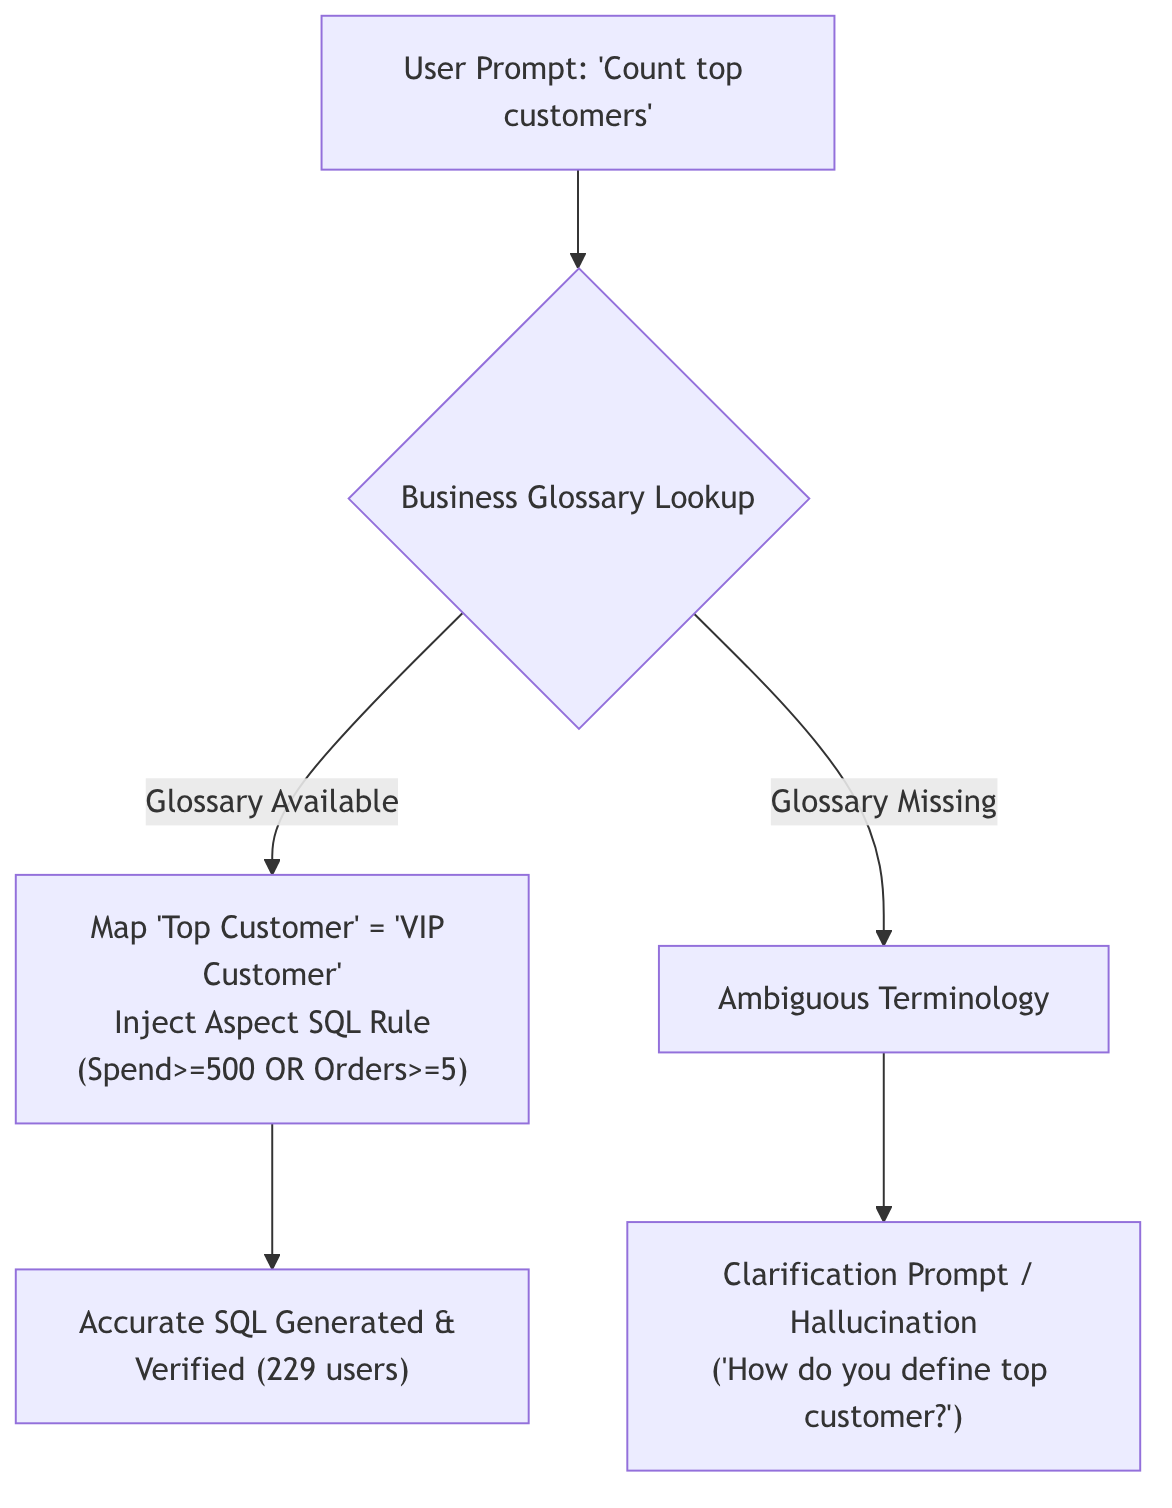

---

### 5. Finalizing Agent Settings & Enterprise Sharing
- **Instructions**: Add enterprise domain guidelines and key identifier definitions (`session_id`, `user_id`, `created_at`, etc.).
- **Verified Queries**: Register 2 gold-standard query pairs for consistent reference.
- **Glossary**: Confirm that all 55 Knowledge Catalog business terms are linked.
- Click **`Save`** to save your agent, click **`Publish`** to deploy the agent version, and then click **`Share`** to grant access to team collaborators.

---

### 6. Additional Conversational Test Scenarios

For detailed Dataplex `sql-mapping` Aspect definitions and complete Text-to-SQL reference queries, refer to [agent_test_queries.md](../resources/agent_test_queries.md).

1. **Cart Abandonment Trend Analysis**:
   - `"Calculate the cart abandonment rate by acquisition marketing channel and sort in descending order."`
2. **Product Margin & Refund Correlation**:
   - `"For women's apparel with a product margin of 40% or higher, calculate the refund rate by brand."`
3. **Dormant User Acquisition Ingestion**:
   - `"What were the top 3 acquisition channels for users who are currently dormant?"`